# Figure 2c and Extended Data Fig. 1c - GNAS, per haplotype

Drawn by NanoMethViz from the phased reads. The whole-genome BAMs are 85 GB and 53 GB;
cut to the ninety imprinting control regions they are 38 and 19 MB per haplotype, which
is what `data/icr_bam/` holds.

NanoMethViz is installed from Bioconductor at build time, because bioconda carries only
2.4.0 against the 3.2.0 the paper used. That is a source build and it can fail. The first
cell says which of the two you are looking at.

In [1]:
import sys; sys.path.insert(0, "../scripts"); sys.path.insert(0, "../scripts/paper")
from pathlib import Path
from nbkit import setup, paper_py, paper_r, run_r_source, harvest, show, have_r_package, DATA

OUT = setup("../figures/notebook")
print("panels will be written to", OUT)

# %%R cells below run R natively in this kernel through rpy2, so the R panels are R code
# in the notebook rather than a string that gets written to a file.
%load_ext rpy2.ipython

panels will be written to ./figures/notebook


$HOME_DIR/conda/envs/lvfig_r/lib/R/bin/exec/R: $HOME/.conda/envs/r_arrow_env/lib/libpcre2-8.so.0: no version information available (required by $HOME/.conda/pkgs/r-base-4.4.3-h835929b_7/lib/R/bin/exec/../../lib/libR.so)


## Is NanoMethViz in this environment?

In [2]:
if have_r_package("NanoMethViz"):
    print("yes: the cells below draw the panels from data/icr_bam/")
else:
    print("no: the R cells below will stop. Use the last cell, which shows")
    print("the figure the paper's own run produced.")

no: the R cells below will stop. Use the last cell, which shows
the figure the paper's own run produced.


## GNAS, ONT

The paper's NanoMethViz script, inlined. `parse_args` is given its arguments directly because a notebook has no command line; that one line is marked in the code.

In [3]:
%%R
## scripts/paper/modbam_region_plot.R, run as R. Edit any line and re-run the cell.

#!/usr/bin/env Rscript
rm(list = ls())

library(argparser)
library(NanoMethViz)
library(dplyr)
library(rtracklayer)
library(GenomicRanges)

# ---------------------------------------------------------------------------
# NanoMethViz region plot for two ModBAM files (HP1 vs HP2) on T2T (hs1) coords
#
# Example:
# Rscript modbam_nanomethviz_hp_region_plot.R \
#   --hp1_bam /path/to/HP1.bam \
#   --hp2_bam /path/to/HP2.bam \
#   --chr chr11 --start 118453794 --end 118548121 \
#   --flank 5000 --tagname KMT2A --svg
# ---------------------------------------------------------------------------
parser <- arg_parser(
	"Plot NanoMethViz methylation tracks at a user-defined region from two ModBAM files (HP1, HP2)."
)

parser <- add_argument(parser, "--hp1_bam", help = "HP1 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp2_bam", help = "HP2 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp1_name", help = "HP1 sample name in plot", type = "character", default = "HP1")
parser <- add_argument(parser, "--hp2_name", help = "HP2 sample name in plot", type = "character", default = "HP2")
parser <- add_argument(parser, "--chr", help = "Chromosome (T2T, e.g. chr11)", type = "character")
parser <- add_argument(parser, "--start", help = "Region start coordinate", type = "integer")
parser <- add_argument(parser, "--end", help = "Region end coordinate", type = "integer")
parser <- add_argument(parser, "--flank", help = "Flanking bp added to start/end", type = "integer", default = 2000)
parser <- add_argument(
	parser, "--gtf_file", help = "T2T GTF annotation file (hs1.ncbiRefSeq.gtf)",
	type = "character",
	default = "/project2/sli68423_1316/users/yang/reference/chm13v2.0/genes/hs1.ncbiRefSeq.gtf"
)
parser <- add_argument(parser, "--wdir", help = "Working directory", type = "character", default = ".")
parser <- add_argument(parser, "--outdir", help = "Output directory for plots", type = "character", default = "modbam_plots")
parser <- add_argument(parser, "--outfn_prefix", help = "Output file name prefix", type = "character", default = "nanomethviz_hp_region")
parser <- add_argument(parser, "--tagname", help = "Tag appended to output file name", type = "character", default = "")
parser <- add_argument(parser, "--fig_w", help = "Figure width (inches)", type = "integer", default = 8)
parser <- add_argument(parser, "--fig_h", help = "Figure height (inches)", type = "integer", default = 7)
parser <- add_argument(parser, "--avg_method", help = "Aggregation method: mean or median", type = "character", default = "mean")
parser <- add_argument(parser, "--smoothing_window", help = "Smoothing window (bp)", type = "integer", default = 2000)
parser <- add_argument(parser, "--heatmap_subsample", help = "Heatmap subsample size", type = "integer", default = 200)
parser <- add_argument(parser, "--hp1_color", help = "HP1 track color", type = "character", default = "#E41A1C")
parser <- add_argument(parser, "--hp2_color", help = "HP2 track color", type = "character", default = "#377EB8")
parser <- add_argument(parser, "--svg", help = "Also save SVG output", flag = TRUE)
parser <- add_argument(parser, "--png", help = "Also save PNG output", flag = TRUE)
parser <- add_argument(parser, "--png_dpi", help = "PNG resolution (dpi)", type = "integer", default = 600)
parser <- add_argument(parser, "--no_gene_anno", help = "Hide gene annotation track", flag = TRUE)

## parse_args given its arguments directly; a notebook has no command line.
args <- parse_args(parser, c("--hp1_bam", file.path(Sys.getenv("LV_DATA"), "icr_bam/hg002_ont_icr_HP1.bam"), "--hp2_bam", file.path(Sys.getenv("LV_DATA"), "icr_bam/hg002_ont_icr_HP2.bam"), "--chr", "chr20", "--start", "60617123", "--end", "60644527", "--gtf_file", file.path(Sys.getenv("LV_DATA"), "icr_bam/hs1.ncbiRefSeq.icr.gtf"), "--outdir", Sys.getenv("LV_OUT"), "--outfn_prefix", "gnas_ont", "--fig_w", "7", "--fig_h", "6"))
str(args)

if (args$start >= args$end) {
	stop("--start must be less than --end")
}

required_files <- c(args$hp1_bam, args$hp2_bam, args$gtf_file)
missing_files <- required_files[!file.exists(required_files)]
if (length(missing_files) > 0) {
	stop("Missing input file(s):\n", paste(missing_files, collapse = "\n"))
}

if (!dir.exists(args$wdir)) {
	stop("wdir not found: ", args$wdir)
}
setwd(args$wdir)

outdir <- args$outdir
if (!dir.exists(outdir)) {
	dir.create(outdir, recursive = TRUE, showWarnings = FALSE)
}

# ---------------------------------------------------------------------------
# T2T exon annotation (shared style with prior NanoMethViz scripts)
# ---------------------------------------------------------------------------
get_all_exon <- function(gtf_df) {
	exon_df <- gtf_df[gtf_df$type == "exon", ]
	exon_table <- exon_df %>%
		dplyr::select(
			gene_id = gene_id,
			chr = seqnames,
			strand = strand,
			start = start,
			end = end,
			transcript_id = transcript_id,
			symbol = gene_name
		)
	tibble::as_tibble(exon_table)
}

get_region_exons <- function(exon_tibble, chr, region_start, region_end) {
	region_gr <- GRanges(
		seqnames = chr,
		ranges = IRanges(start = region_start, end = region_end)
	)
	exon_gr <- GRanges(
		seqnames = exon_tibble$chr,
		ranges = IRanges(start = exon_tibble$start, end = exon_tibble$end)
	)
	hits <- findOverlaps(exon_gr, region_gr)
	tibble::as_tibble(exon_tibble[queryHits(hits), , drop = FALSE])
}

gtf_data <- import(args$gtf_file)
gtf_df <- as.data.frame(gtf_data)

region_start <- max(1L, args$start - args$flank)
region_end <- args$end + args$flank
exon_tibble <- get_region_exons(
	get_all_exon(gtf_df),
	chr = args$chr,
	region_start = region_start,
	region_end = region_end
)

if (nrow(exon_tibble) == 0) {
	warning("No exons overlap region ", args$chr, ":", region_start, "-", region_end)
}

# ---------------------------------------------------------------------------
# Build ModBAM NanoMethViz object (HP1 vs HP2)
# ---------------------------------------------------------------------------
sample_names <- c(args$hp1_name, args$hp2_name)
bam_files <- c(args$hp1_bam, args$hp2_bam)
group_names <- sample_names

mbr <- ModBamResult(
	methy = ModBamFiles(
		samples = sample_names,
		bam_files
	),
	samples = data.frame(
		sample = sample_names,
		group = group_names,
		stringsAsFactors = FALSE
	),
	exons = exon_tibble
)

grange <- GRanges(
	seqnames = args$chr,
	ranges = IRanges(start = region_start, end = region_end)
)

palette1 <- ggplot2::scale_colour_manual(
	values = stats::setNames(c(args$hp1_color, args$hp2_color), sample_names)
)

show_gene_anno <- !args$no_gene_anno

np1 <- plot_grange(
	mbr,
	grange,
	palette = palette1,
	avg_method = args$avg_method,
	smoothing_window = args$smoothing_window,
	heatmap_subsample = args$heatmap_subsample,
	gene_anno = show_gene_anno
)

# ---------------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------------
if (nzchar(args$tagname)) {
	out_prefix <- sprintf("%s_%s", args$outfn_prefix, args$tagname)
} else {
	out_prefix <- sprintf(
		"%s_%s_%d_%d",
		args$outfn_prefix,
		gsub("^chr", "", args$chr),
		args$start,
		args$end
	)
}

save_plot <- function(device_fn, width, height, ...) {
	graphics.off()
	device_fn(file.path(outdir, outfn), width = width, height = height, ...)
	print(np1)
	dev.off()
}

outfn <- sprintf("%s.pdf", out_prefix)
save_plot(pdf, args$fig_w, args$fig_h)
cat("Saved to", file.path(outdir, outfn), "\n")

if (args$svg) {
	outfn <- sprintf("%s.svg", out_prefix)
	save_plot(svg, args$fig_w, args$fig_h)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

if (args$png) {
	outfn <- sprintf("%s.png", out_prefix)
	save_plot(
		png,
		args$fig_w,
		args$fig_h,
		units = "in",
		res = args$png_dpi
	)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

rdata_fn <- file.path(outdir, sprintf("%s.RData", out_prefix))
save.image(rdata_fn)
cat("Saved workspace to", rdata_fn, "\n")

cat("### Done\n")

Error in library(NanoMethViz) : there is no package called ‘NanoMethViz’


RInterpreterError: Failed to parse and evaluate line '## scripts/paper/modbam_region_plot.R, run as R. Edit any line and re-run the cell.\n\n#!/usr/bin/env Rscript\nrm(list = ls())\n\nlibrary(argparser)\nlibrary(NanoMethViz)\nlibrary(dplyr)\nlibrary(rtracklayer)\nlibrary(GenomicRanges)\n\n# ---------------------------------------------------------------------------\n# NanoMethViz region plot for two ModBAM files (HP1 vs HP2) on T2T (hs1) coords\n#\n# Example:\n# Rscript modbam_nanomethviz_hp_region_plot.R \\\n#   --hp1_bam /path/to/HP1.bam \\\n#   --hp2_bam /path/to/HP2.bam \\\n#   --chr chr11 --start 118453794 --end 118548121 \\\n#   --flank 5000 --tagname KMT2A --svg\n# ---------------------------------------------------------------------------\nparser <- arg_parser(\n\t"Plot NanoMethViz methylation tracks at a user-defined region from two ModBAM files (HP1, HP2)."\n)\n\nparser <- add_argument(parser, "--hp1_bam", help = "HP1 ModBAM file path", type = "character")\nparser <- add_argu

In [4]:
show('gnas_ont.png')

  not produced: gnas_ont.png


## GNAS, PacBio

The same script, the other platform's reads.

In [5]:
%%R
## scripts/paper/modbam_region_plot.R, run as R. Edit any line and re-run the cell.

#!/usr/bin/env Rscript
rm(list = ls())

library(argparser)
library(NanoMethViz)
library(dplyr)
library(rtracklayer)
library(GenomicRanges)

# ---------------------------------------------------------------------------
# NanoMethViz region plot for two ModBAM files (HP1 vs HP2) on T2T (hs1) coords
#
# Example:
# Rscript modbam_nanomethviz_hp_region_plot.R \
#   --hp1_bam /path/to/HP1.bam \
#   --hp2_bam /path/to/HP2.bam \
#   --chr chr11 --start 118453794 --end 118548121 \
#   --flank 5000 --tagname KMT2A --svg
# ---------------------------------------------------------------------------
parser <- arg_parser(
	"Plot NanoMethViz methylation tracks at a user-defined region from two ModBAM files (HP1, HP2)."
)

parser <- add_argument(parser, "--hp1_bam", help = "HP1 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp2_bam", help = "HP2 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp1_name", help = "HP1 sample name in plot", type = "character", default = "HP1")
parser <- add_argument(parser, "--hp2_name", help = "HP2 sample name in plot", type = "character", default = "HP2")
parser <- add_argument(parser, "--chr", help = "Chromosome (T2T, e.g. chr11)", type = "character")
parser <- add_argument(parser, "--start", help = "Region start coordinate", type = "integer")
parser <- add_argument(parser, "--end", help = "Region end coordinate", type = "integer")
parser <- add_argument(parser, "--flank", help = "Flanking bp added to start/end", type = "integer", default = 2000)
parser <- add_argument(
	parser, "--gtf_file", help = "T2T GTF annotation file (hs1.ncbiRefSeq.gtf)",
	type = "character",
	default = "/project2/sli68423_1316/users/yang/reference/chm13v2.0/genes/hs1.ncbiRefSeq.gtf"
)
parser <- add_argument(parser, "--wdir", help = "Working directory", type = "character", default = ".")
parser <- add_argument(parser, "--outdir", help = "Output directory for plots", type = "character", default = "modbam_plots")
parser <- add_argument(parser, "--outfn_prefix", help = "Output file name prefix", type = "character", default = "nanomethviz_hp_region")
parser <- add_argument(parser, "--tagname", help = "Tag appended to output file name", type = "character", default = "")
parser <- add_argument(parser, "--fig_w", help = "Figure width (inches)", type = "integer", default = 8)
parser <- add_argument(parser, "--fig_h", help = "Figure height (inches)", type = "integer", default = 7)
parser <- add_argument(parser, "--avg_method", help = "Aggregation method: mean or median", type = "character", default = "mean")
parser <- add_argument(parser, "--smoothing_window", help = "Smoothing window (bp)", type = "integer", default = 2000)
parser <- add_argument(parser, "--heatmap_subsample", help = "Heatmap subsample size", type = "integer", default = 200)
parser <- add_argument(parser, "--hp1_color", help = "HP1 track color", type = "character", default = "#E41A1C")
parser <- add_argument(parser, "--hp2_color", help = "HP2 track color", type = "character", default = "#377EB8")
parser <- add_argument(parser, "--svg", help = "Also save SVG output", flag = TRUE)
parser <- add_argument(parser, "--png", help = "Also save PNG output", flag = TRUE)
parser <- add_argument(parser, "--png_dpi", help = "PNG resolution (dpi)", type = "integer", default = 600)
parser <- add_argument(parser, "--no_gene_anno", help = "Hide gene annotation track", flag = TRUE)

## parse_args given its arguments directly; a notebook has no command line.
args <- parse_args(parser, c("--hp1_bam", file.path(Sys.getenv("LV_DATA"), "icr_bam/hg002_pacbio_icr_HP1.bam"), "--hp2_bam", file.path(Sys.getenv("LV_DATA"), "icr_bam/hg002_pacbio_icr_HP2.bam"), "--chr", "chr20", "--start", "60617123", "--end", "60644527", "--gtf_file", file.path(Sys.getenv("LV_DATA"), "icr_bam/hs1.ncbiRefSeq.icr.gtf"), "--outdir", Sys.getenv("LV_OUT"), "--outfn_prefix", "gnas_pacbio", "--fig_w", "7", "--fig_h", "6"))
str(args)

if (args$start >= args$end) {
	stop("--start must be less than --end")
}

required_files <- c(args$hp1_bam, args$hp2_bam, args$gtf_file)
missing_files <- required_files[!file.exists(required_files)]
if (length(missing_files) > 0) {
	stop("Missing input file(s):\n", paste(missing_files, collapse = "\n"))
}

if (!dir.exists(args$wdir)) {
	stop("wdir not found: ", args$wdir)
}
setwd(args$wdir)

outdir <- args$outdir
if (!dir.exists(outdir)) {
	dir.create(outdir, recursive = TRUE, showWarnings = FALSE)
}

# ---------------------------------------------------------------------------
# T2T exon annotation (shared style with prior NanoMethViz scripts)
# ---------------------------------------------------------------------------
get_all_exon <- function(gtf_df) {
	exon_df <- gtf_df[gtf_df$type == "exon", ]
	exon_table <- exon_df %>%
		dplyr::select(
			gene_id = gene_id,
			chr = seqnames,
			strand = strand,
			start = start,
			end = end,
			transcript_id = transcript_id,
			symbol = gene_name
		)
	tibble::as_tibble(exon_table)
}

get_region_exons <- function(exon_tibble, chr, region_start, region_end) {
	region_gr <- GRanges(
		seqnames = chr,
		ranges = IRanges(start = region_start, end = region_end)
	)
	exon_gr <- GRanges(
		seqnames = exon_tibble$chr,
		ranges = IRanges(start = exon_tibble$start, end = exon_tibble$end)
	)
	hits <- findOverlaps(exon_gr, region_gr)
	tibble::as_tibble(exon_tibble[queryHits(hits), , drop = FALSE])
}

gtf_data <- import(args$gtf_file)
gtf_df <- as.data.frame(gtf_data)

region_start <- max(1L, args$start - args$flank)
region_end <- args$end + args$flank
exon_tibble <- get_region_exons(
	get_all_exon(gtf_df),
	chr = args$chr,
	region_start = region_start,
	region_end = region_end
)

if (nrow(exon_tibble) == 0) {
	warning("No exons overlap region ", args$chr, ":", region_start, "-", region_end)
}

# ---------------------------------------------------------------------------
# Build ModBAM NanoMethViz object (HP1 vs HP2)
# ---------------------------------------------------------------------------
sample_names <- c(args$hp1_name, args$hp2_name)
bam_files <- c(args$hp1_bam, args$hp2_bam)
group_names <- sample_names

mbr <- ModBamResult(
	methy = ModBamFiles(
		samples = sample_names,
		bam_files
	),
	samples = data.frame(
		sample = sample_names,
		group = group_names,
		stringsAsFactors = FALSE
	),
	exons = exon_tibble
)

grange <- GRanges(
	seqnames = args$chr,
	ranges = IRanges(start = region_start, end = region_end)
)

palette1 <- ggplot2::scale_colour_manual(
	values = stats::setNames(c(args$hp1_color, args$hp2_color), sample_names)
)

show_gene_anno <- !args$no_gene_anno

np1 <- plot_grange(
	mbr,
	grange,
	palette = palette1,
	avg_method = args$avg_method,
	smoothing_window = args$smoothing_window,
	heatmap_subsample = args$heatmap_subsample,
	gene_anno = show_gene_anno
)

# ---------------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------------
if (nzchar(args$tagname)) {
	out_prefix <- sprintf("%s_%s", args$outfn_prefix, args$tagname)
} else {
	out_prefix <- sprintf(
		"%s_%s_%d_%d",
		args$outfn_prefix,
		gsub("^chr", "", args$chr),
		args$start,
		args$end
	)
}

save_plot <- function(device_fn, width, height, ...) {
	graphics.off()
	device_fn(file.path(outdir, outfn), width = width, height = height, ...)
	print(np1)
	dev.off()
}

outfn <- sprintf("%s.pdf", out_prefix)
save_plot(pdf, args$fig_w, args$fig_h)
cat("Saved to", file.path(outdir, outfn), "\n")

if (args$svg) {
	outfn <- sprintf("%s.svg", out_prefix)
	save_plot(svg, args$fig_w, args$fig_h)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

if (args$png) {
	outfn <- sprintf("%s.png", out_prefix)
	save_plot(
		png,
		args$fig_w,
		args$fig_h,
		units = "in",
		res = args$png_dpi
	)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

rdata_fn <- file.path(outdir, sprintf("%s.RData", out_prefix))
save.image(rdata_fn)
cat("Saved workspace to", rdata_fn, "\n")

cat("### Done\n")

Error in library(NanoMethViz) : there is no package called ‘NanoMethViz’


RInterpreterError: Failed to parse and evaluate line '## scripts/paper/modbam_region_plot.R, run as R. Edit any line and re-run the cell.\n\n#!/usr/bin/env Rscript\nrm(list = ls())\n\nlibrary(argparser)\nlibrary(NanoMethViz)\nlibrary(dplyr)\nlibrary(rtracklayer)\nlibrary(GenomicRanges)\n\n# ---------------------------------------------------------------------------\n# NanoMethViz region plot for two ModBAM files (HP1 vs HP2) on T2T (hs1) coords\n#\n# Example:\n# Rscript modbam_nanomethviz_hp_region_plot.R \\\n#   --hp1_bam /path/to/HP1.bam \\\n#   --hp2_bam /path/to/HP2.bam \\\n#   --chr chr11 --start 118453794 --end 118548121 \\\n#   --flank 5000 --tagname KMT2A --svg\n# ---------------------------------------------------------------------------\nparser <- arg_parser(\n\t"Plot NanoMethViz methylation tracks at a user-defined region from two ModBAM files (HP1, HP2)."\n)\n\nparser <- add_argument(parser, "--hp1_bam", help = "HP1 ModBAM file path", type = "character")\nparser <- add_argu

In [6]:
show('gnas_pacbio.png')

  not produced: gnas_pacbio.png


## If NanoMethViz is not here

The figures the paper's own run produced, included so the repository shows every panel. These are **not** a redraw.

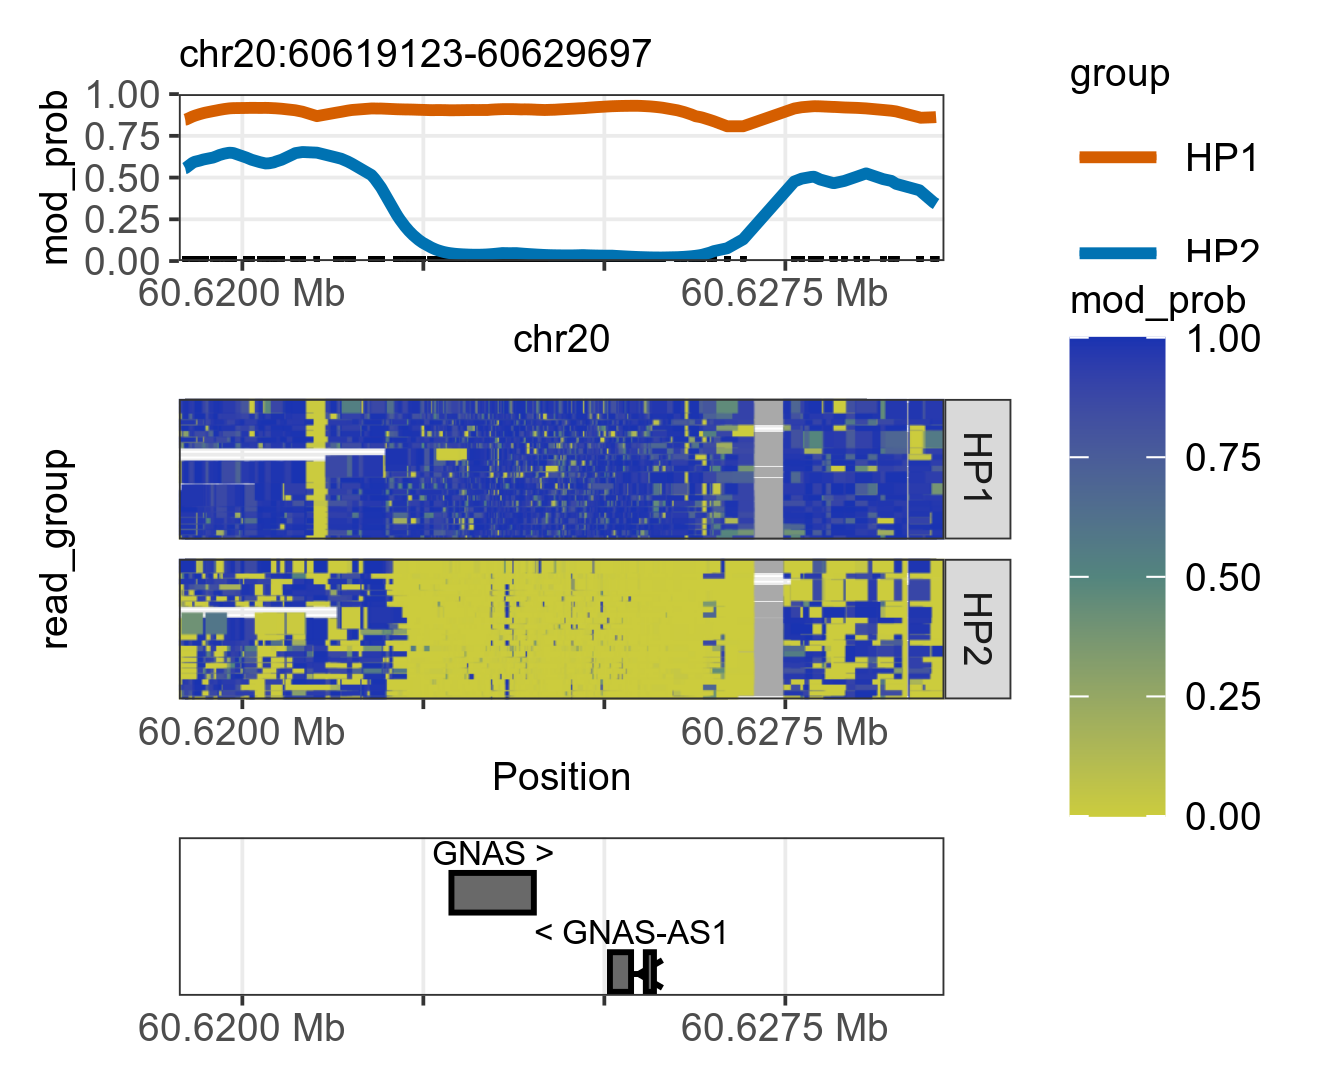

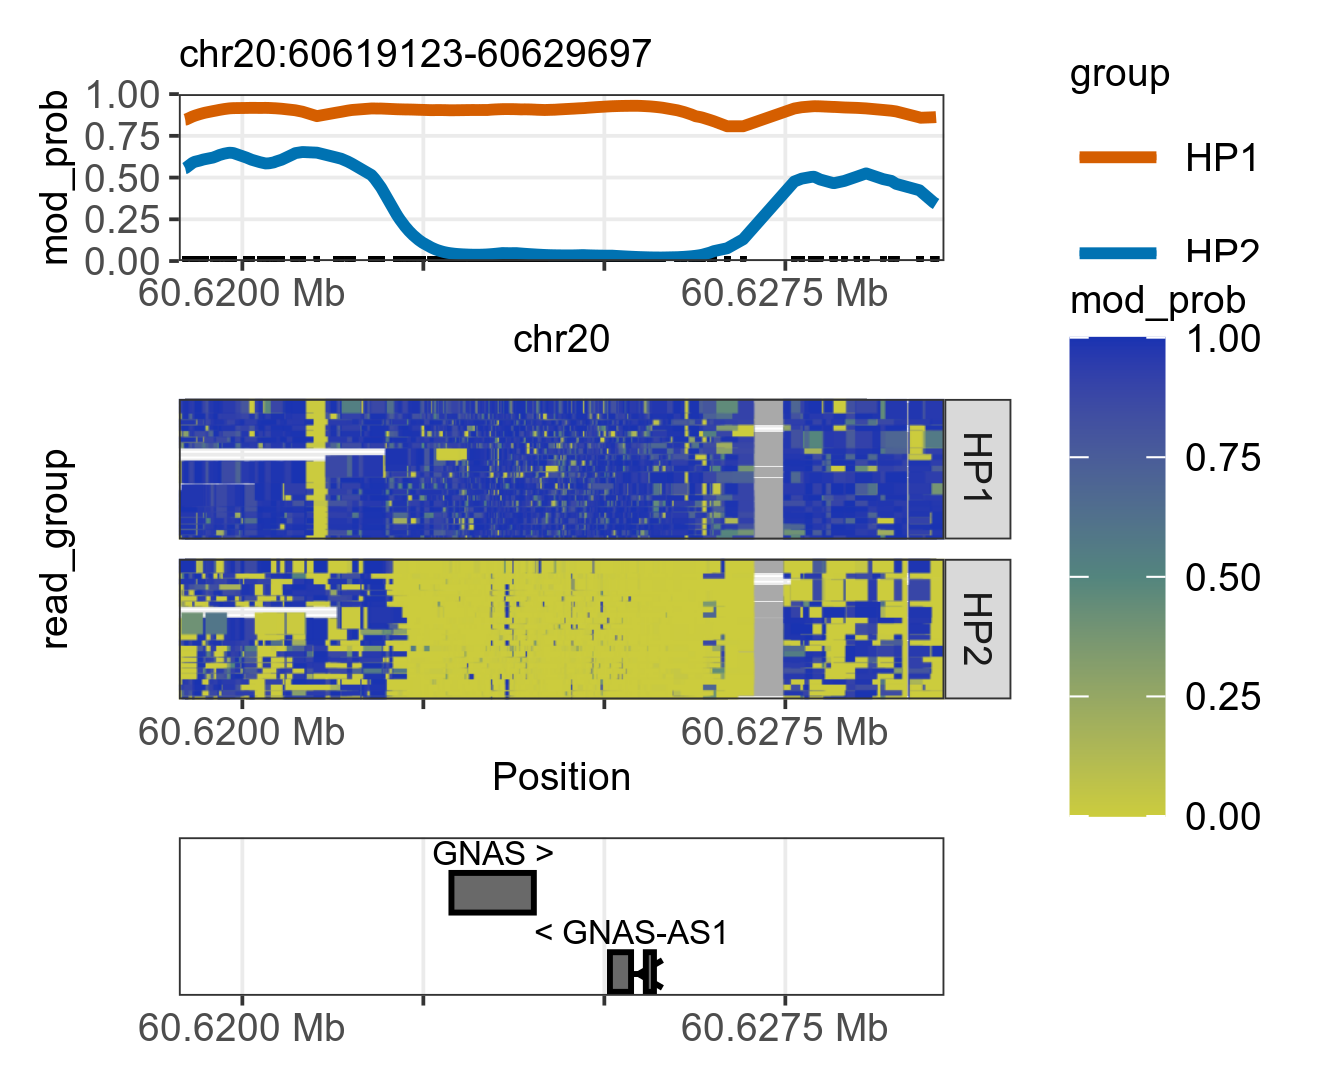

In [7]:
from IPython.display import Image, display
for n in ("panel_modbam_human_GNAS.png", "panel_modbam_agent_GNAS.png"):
    display(Image(filename=f"../data/reference_panels/{n}"))